In [33]:
# Parameters
param1=1

In [2]:
import importlib
import run_sim
import data_modules
import utils
import utils_plot

importlib.reload(run_sim)
importlib.reload(data_modules)
importlib.reload(utils)
importlib.reload(utils_plot)


<module 'utils_plot' from '/home/avivra/Desktop/project/RepresentationShaping/utils_plot.py'>

In [35]:
import torch
import numpy as np
from copy import deepcopy
import pickle as pkl

from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, run_sim_wrapper, create_data
from utils import *
from utils_plot import *
from tqdm import tqdm
from utils import *
from functools import reduce
import os
from joblib import Parallel, delayed
import shutil


In [13]:
C = Config()

C.G = 0.5
C.linear_net = False
C.learning_rate = 0.0001
C.data_geometry = 'non_linear_fn'
C.L=10
C.print_progress = True
C.length_corridors = [10]*1
C.angle_range = np.pi/10
C.hidden_size = 250 # (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs = 10000
C.algo_name = 'Adam'
C.loss_fn = nn.MSELoss()

C.s_range = (-1.0, 1.0)
C.poly_degree = 10
C.num_samples = 1000
C.function_dim = 1
C.max_move = 0.3
C.discrete_samples = False
var_name = 'max_move'
var_values = np.logspace(-3, 0, 20)
# var_name = 'L'
# var_values = np.arange(1, 10)

In [ ]:
num_gpus = 8

# Ensure the results directory exists
results_dir = f'results/notebook_results/{var_name}'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

def run_and_save(var_value, index):
    C_local = deepcopy(C)
    setattr(C_local, var_name, var_value)
    C_local.gpu_id = index % num_gpus
    data_dict = run_sim_wrapper(C_local)
    out_path = os.path.join(results_dir, f'data_dict_{getattr(C_local, var_name)}.pkl')
    # Remove 'state_dict_l' and 'hidden_l' from data_dict if they exist
    data_dict.pop('state_dict_l', None)
    data_dict.pop('hidden_l', None)
    with open(out_path, 'wb') as f:
        pkl.dump(data_dict, f)
    return out_path

# Run in parallel
paths = Parallel(n_jobs=-1)(
    delayed(run_and_save)(var_value, index) for index, var_value in enumerate(var_values)
)
# Load all results into data_dict_l
data_dict_l = []
for path in paths:
    with open(path, 'rb') as f:
        data_dict_l.append(pkl.load(f))

for data_dict in data_dict_l:
    print(f'{var_name}: {getattr(data_dict["C"], var_name)} --- X shape: {data_dict["X"].shape} --- Number of hidden: {data_dict["C"].hidden_size}')

Number of samples: 731
Input dimension: 2
Output dimension: 1
Function dimension: 1
Action range: [-1.0, 1.0]
Parameter s range: (-1.0, 1.0)
Number of actions: 1

Sig_2 of last hidden: 5.179275411326678e-12
Number of samples: 1000
Input dimension: 2
Output dimension: 1
Function dimension: 1
Action range: [-0.002976351441631319, 0.002976351441631319]
Parameter s range: (-1.0, 1.0)
Number of actions: 1

Sig_2 of last hidden: 4.103099370683649e-12


  0%|          | 7/10000 [00:00<08:18, 20.04it/s]

Number of samples: 1000
Input dimension: 2
Output dimension: 1
Function dimension: 1
Action range: [-0.00206913808111479, 0.00206913808111479]
Parameter s range: (-1.0, 1.0)
Number of actions: 1

Sig_2 of last hidden: 4.103147075579239e-12


  0%|          | 49/10000 [00:02<06:06, 27.16it/s]

Number of samples: 866
Input dimension: 2
Output dimension: 1
Function dimension: 1
Action range: [-0.4832930238571752, 0.4832930238571752]
Parameter s range: (-1.0, 1.0)
Number of actions: 1

Sig_2 of last hidden: 4.246816873859638e-12
Number of samples: 991
Input dimension: 2
Output dimension: 1
Function dimension: 1
Action range: [-0.0379269019073225, 0.0379269019073225]
Parameter s range: (-1.0, 1.0)
Number of actions: 1

Sig_2 of last hidden: 4.126836459367178e-12


...

  0%|          | 0/10000 [00:00<?, ?it/s]29.11it/s]

Number of samples: 997
Input dimension: 2
Output dimension: 1
Function dimension: 1
Action range: [-0.012742749857031334, 0.012742749857031334]
Parameter s range: (-1.0, 1.0)
Number of actions: 1

Sig_2 of last hidden: 4.111037465309719e-12
Number of samples: 998
Input dimension: 2
Output dimension: 1
Function dimension: 1
Action range: [-0.006158482110660267, 0.006158482110660267]
Parameter s range: (-1.0, 1.0)
Number of actions: 1

Sig_2 of last hidden: 4.108911995370779e-12
Number of samples: 997
Input dimension: 2
Output dimension: 1
Function dimension: 1
Action range: [-0.008858667904100823, 0.008858667904100823]
Parameter s range: (-1.0, 1.0)
Number of actions: 1

Sig_2 of last hidden: 4.111654593186298e-12
Number of samples: 975
Input dimension: 2
Output dimension: 1
Function dimension: 1
Action range: [-0.11288378916846883, 0.11288378916846883]
Parameter s range: (-1.0, 1.0)
Number of actions: 1

Sig_2 of last hidden: 4.16643108902548e-12
Number of samples: 983
Input dimension:

  0%|          | 0/10000 [00:00<?, ?it/s]6.53it/s]]

Number of samples: 943
Input dimension: 2
Output dimension: 1
Function dimension: 1
Action range: [-0.23357214690901212, 0.23357214690901212]
Parameter s range: (-1.0, 1.0)
Number of actions: 1

Sig_2 of last hidden: 4.1925399783815376e-12
Number of samples: 996
Input dimension: 2
Output dimension: 1
Function dimension: 1
Action range: [-0.018329807108324356, 0.018329807108324356]
Parameter s range: (-1.0, 1.0)
Number of actions: 1

Sig_2 of last hidden: 4.113237962038996e-12
Number of samples: 1000
Input dimension: 2
Output dimension: 1
Function dimension: 1
Action range: [-0.0014384498882876629, 0.0014384498882876629]
Parameter s range: (-1.0, 1.0)
Number of actions: 1

Sig_2 of last hidden: 4.1031622544096535e-12
Number of samples: 994
Input dimension: 2
Output dimension: 1
Function dimension: 1
Action range: [-0.026366508987303583, 0.026366508987303583]
Parameter s range: (-1.0, 1.0)
Number of actions: 1

Sig_2 of last hidden: 4.118147663156879e-12
Number of samples: 987
Input dime

 46%|████▌     | 4591/10000 [02:45<03:17, 27.34it/s]

In [ ]:
def plot_pca(data_dict, title="", axs=None, plot_variable=None):
    loc_y = data_dict['loc_y']
    hidden_states = data_dict['hidden_states']
    action_taken = data_dict['action_taken']
    loss_l = data_dict['loss_l']; accuracy_l = data_dict['accuracy_l']
    y = data_dict['y'].cpu().numpy()
    C = data_dict['C']
    corridor = data_dict['corridor']
    X_np = data_dict['X'].cpu().numpy()
    final_weights = data_dict['final_weights']

    colors = loc_y

    if plot_variable is not None:
        hidden  = data_dict[plot_variable].cpu().numpy()
    else:
        hidden = hidden_states[-1].cpu().detach().numpy()

    PR = calc_PR(hidden)
    if not C.bias and C.linear_net:
        W_effective = get_effective_W_from_model_dict(final_weights).cpu().numpy()
        W_PR = calc_PR(W_effective)
        if C.L == 0:
            U, S, V = np.linalg.svd(W_effective, full_matrices=False)
            hidden = X_np @ U @ np.diag(S)
    else:
        W_PR = 0
    hidden_pr = calc_PR(hidden)
    
    # alignment = alignment_score(hidden[corridor==0], hidden[corridor==1]) if n_corridors > 1 else 0
    order = get_r_2(PCA(n_components=1).fit_transform(hidden), colors)

    pca = PCA().fit(hidden)
    X_reduced = pca.transform(hidden)
    if axs is None:
        fig, axs = plt.subplots(1, 4, figsize=(25/2, 5/2))
        axs[0].set_ylabel(title)
    # Add cumulative explained variance ratio in the first row
    ax1 = axs[0]
    ax1.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    ax1.set_xlabel('Number of Components')
    # ax1.set_ylabel('Cumulative EVR')
    ax1.set_title(f'order = {order:.2f} --- W PR = {W_PR:.2f} --- hidden PR = {hidden_pr:.2f}')
    ax1.set_ylim(-0.1, 1.1)
    
    ax1 = axs[1]
    for cor, marker in zip(np.unique(corridor), markers):
        ax1.scatter(X_reduced[corridor==cor, 0], X_reduced[corridor==cor, 1], c=colors[corridor==cor], cmap='coolwarm', alpha=0.7, marker=marker)
    ax1.set_xlabel(f'Component 1')
    ax1.set_ylabel(f'Component 2'),
    ax1.axis('equal')
    
    ax1 = axs[2]
    ax1.scatter(X_reduced[:, 0], colors, c=colors)

    axs[3].plot(loss_l)
    axs[3].set_yscale('log')
    ax2 = axs[3].twinx()
    ax2.plot(accuracy_l, 'r')
    ax2.set_ylim(-0.1, 1.1)
    axs[3].set_title("Loss")

    plt.tight_layout()

In [ ]:
def calc_metrics(data_dict, i=-1):
    hidden = data_dict['hidden_states'][i].cpu().detach().numpy()
    PR = calc_PR(hidden)
    loc_y = data_dict['loc_y']
    order = get_r_2(PCA(n_components=1).fit_transform(hidden), loc_y)
    return PR, order

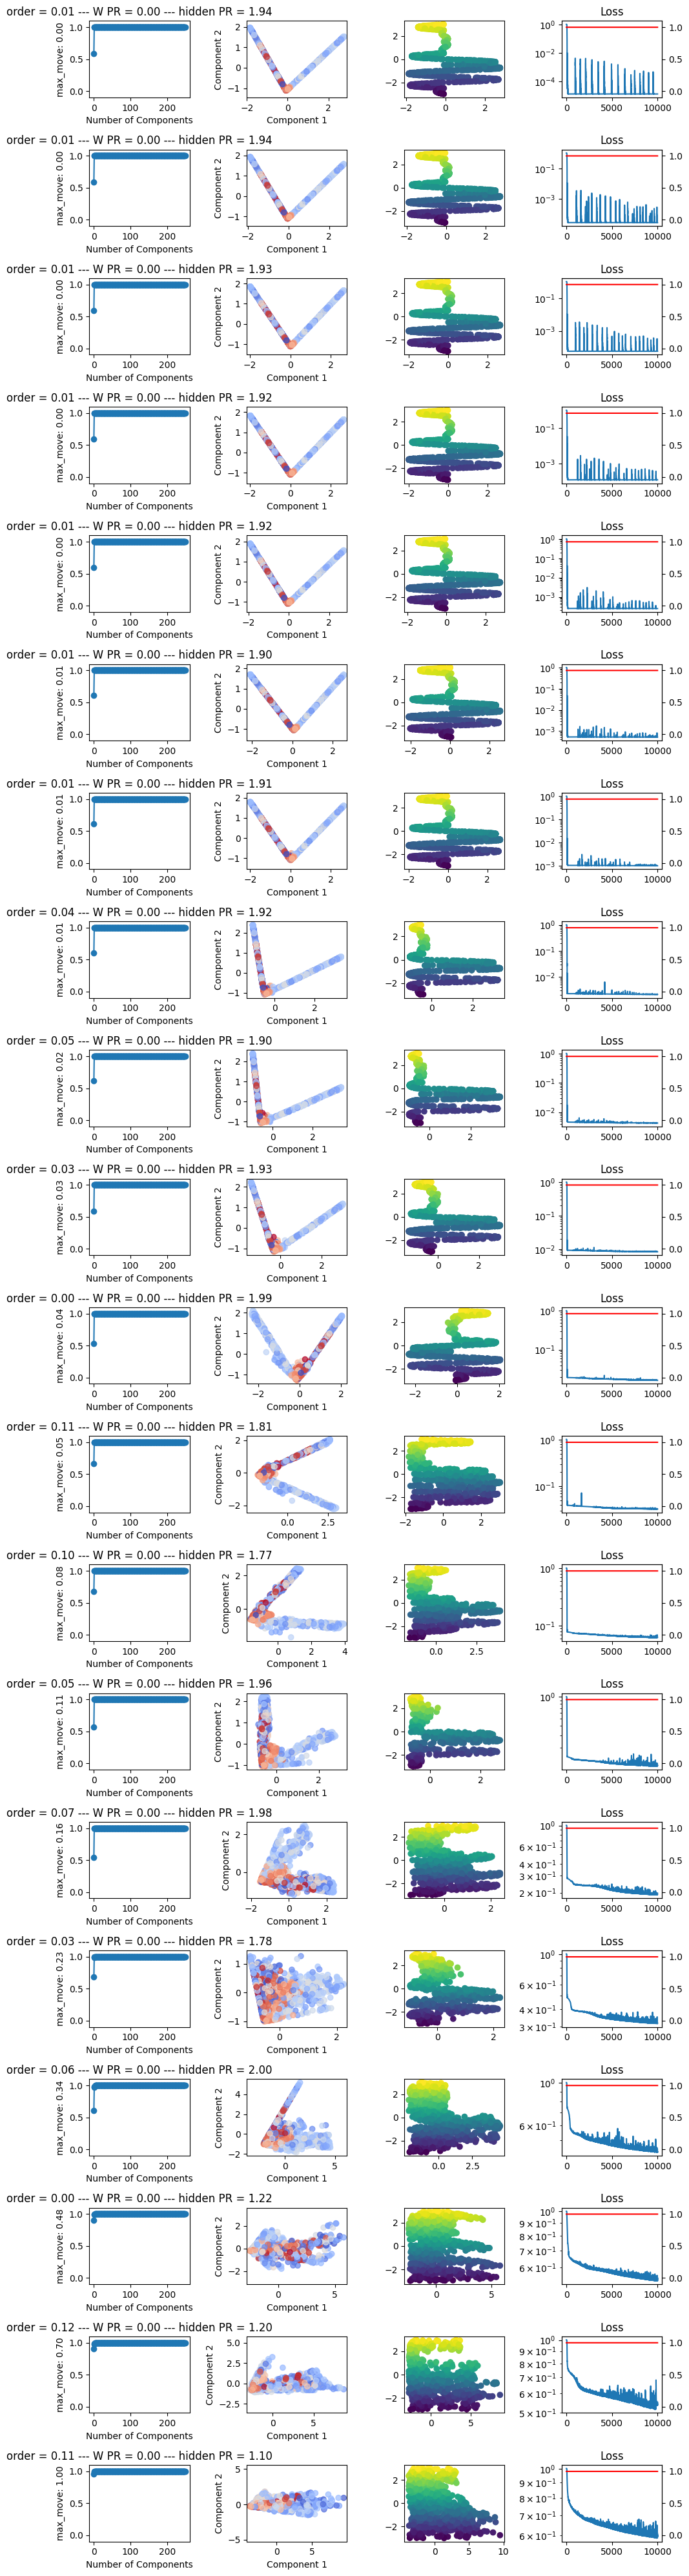

In [ ]:
fig, axs = plt.subplots(len(data_dict_l), 4, figsize=(20/2, len(data_dict_l)*4/2))
for data_dict, axs_current in zip(data_dict_l, axs):
    plot_pca(data_dict, axs=axs_current)
    axs_current[0].set_ylabel(f'{var_name}: {getattr(data_dict["C"], var_name):.2f}')

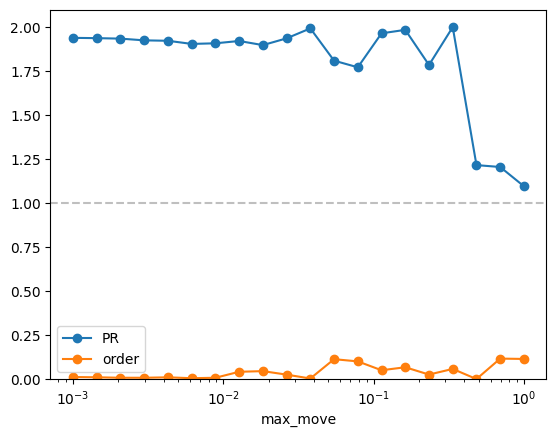

In [ ]:
PR_l = []
order_l = []
for data_dict in data_dict_l:
    PR, order = calc_metrics(data_dict)
    PR_l.append(PR)
    order_l.append(order)
plt.plot(var_values, PR_l, label='PR', marker='o')
plt.plot(var_values, order_l, label='order', marker='o')   
plt.legend()
plt.xlabel(var_name)
plt.ylim(0)
plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
plt.xscale('log')
plt.show()

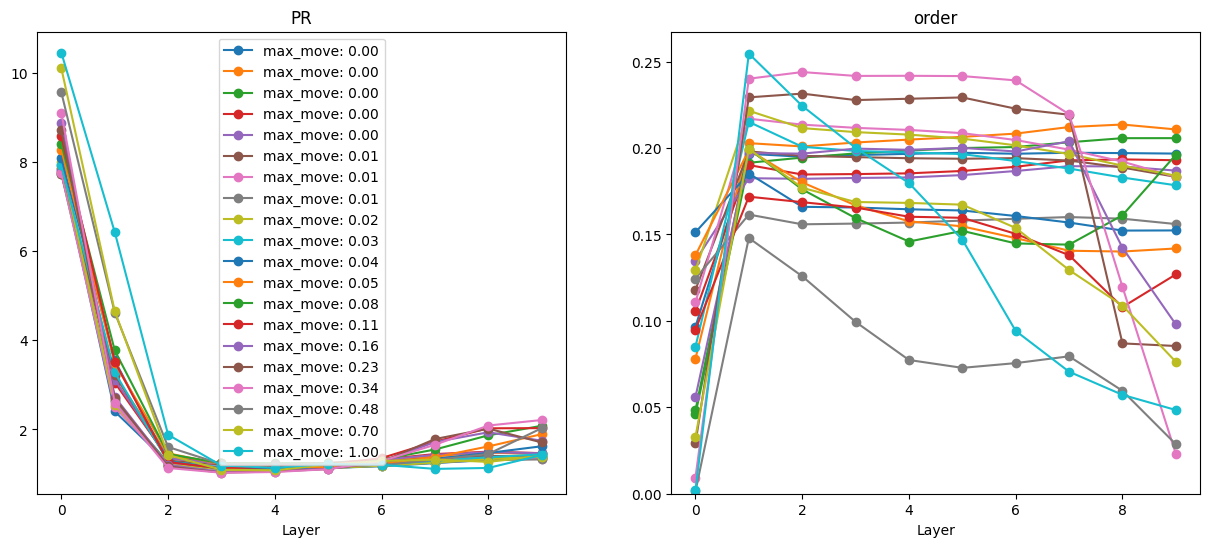

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
for i, data_dict in enumerate(data_dict_l):
    C = data_dict['C']
    PR_l = []
    order_l = []
    for i in range(len(data_dict['hidden_states'])):
        PR, order = calc_metrics(data_dict, i)
        PR_l.append(PR)
        order_l.append(order)
    axs[0].plot(PR_l, label=f'{var_name}: {getattr(C, var_name):.2f}', marker='o')
    axs[1].plot(order_l, label=f'{var_name}: {getattr(C, var_name):.2f}', marker='o')   
axs[0].legend()
axs[0].set_xlabel('Layer')
axs[1].set_xlabel('Layer')
axs[0].set_title('PR')
axs[1].set_title('order')
axs[1].set_ylim(0)
plt.show()

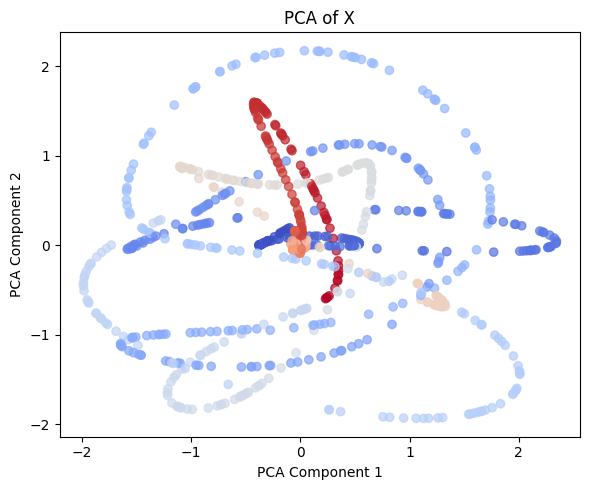

In [ ]:
X = data_dict_l[0]['X'].cpu().numpy()
loc_X = data_dict_l[0]['loc_X']
loc_y = data_dict_l[0]['loc_y']
y = data_dict_l[0]['y'].cpu().numpy()

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=loc_y, cmap='coolwarm', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of X')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1482044/2558676796.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


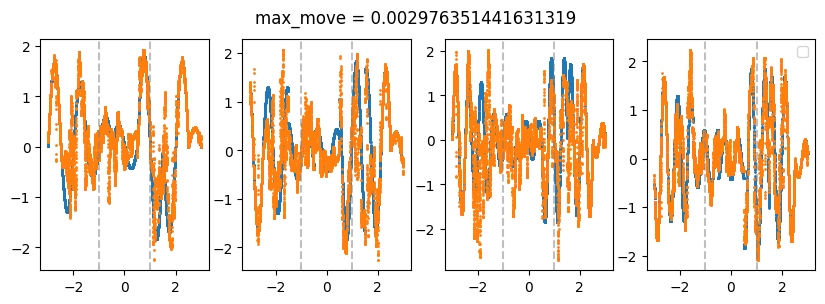

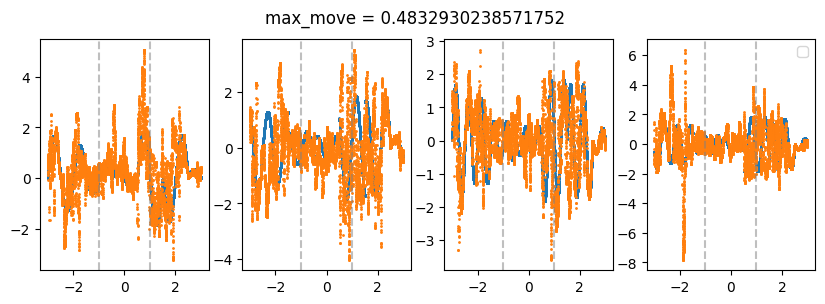

In [ ]:
from data_modules import create_data_non_linear_fn
from model import DNN
C_local = deepcopy(data_dict_l[0]['C'])
C_local.s_range = (-3, 3)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for data_dict in [data_dict_l[3], data_dict_l[-3]]:
    loc_X = data_dict['loc_X']
    outputs = data_dict['outputs']
    X = data_dict['X'].cpu().numpy()
    C_local.num_samples = 10000
    C_local.print_progress = False
    X, y, corridor, loc_X, loc_y, action_taken, dim_l, input_size, output_size, n_actions = create_data(C_local)
    X = torch.tensor(X, dtype=torch.float32).to(device)
    y = torch.tensor(y, dtype=torch.float32).to(device)
    model = DNN(input_size + n_actions, C.hidden_size, output_size, C.L, C.fixed_output, C.linear_net, C.G, C.bias).to(device)
    model.load_state_dict(data_dict['final_weights'])
    outputs = model(X)[0].detach().cpu().numpy()
    X = X.cpu().numpy()
    fig, axs = plt.subplots(1, 4, figsize=(10, 3))
    fig.suptitle(f'max_move = {data_dict["C"].max_move}')
    for i, ax in enumerate(axs):
        ax.scatter(loc_X[:,0], X[:,i], s=1)
        ax.scatter(loc_X[:,0], outputs[:,i], s=1)
        ax.axvline(-1, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(1, color='gray', linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()


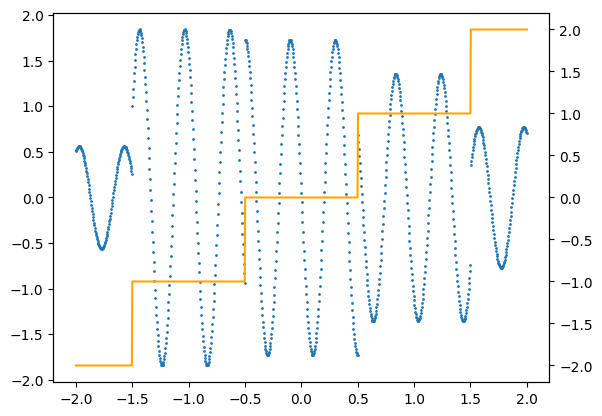

In [ ]:
s = np.linspace(-2, 2, 1000)
distorter = np.round(s*1)
rand_params = np.random.uniform(-2, 2, 9)
f = rand_params[distorter.astype(int)]*np.sin(2*np.pi*s * (1 + i * 0.5) + distorter)
plt.scatter(s, f, s=1)
plt.gca().twinx().plot(s, distorter, c='orange')
plt.show()
